# 01. EDA — Predicting Electric Vehicle Purchases (S6E9)

EV を購入するか (`Will_Buy_EV`) を予測する二値分類。評価指標は ROC-AUC。

## このノートブックの流れ

1. **説明変数を1つずつ目的変数と突き合わせる** — 件数と購入率を並べて見て、単変量で何が効くかを確かめる
2. **単変量の考察をまとめる** — そこから次に検証すべきことを決める
3. **組み合わせ(交差)を調べる** — 単変量で説明しきれない効果があるかを確かめる
4. **次工程に渡すものを決める**

ここで得た結論が、そのまま `02_baseline` 以降の施策につながる。

> 図をまとめて `datacheck/` に保存したい場合は `uv run src/01_eda.py` を実行する。

In [1]:
import os, sys
# リポジトリルートを作業ディレクトリにして、data/ などの相対パスを揃える
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.abspath("src"))
# 絶対パスは出力しない(公開リポジトリに個人のディレクトリ構成を残さないため)
print("data/ を検出:", os.path.isdir("data"))

data/ を検出: True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TARGET = "Will_Buy_EV"
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# 購入を 1、非購入を 0 にした系列。以降の購入率はすべてこれの平均で出す
y = (train[TARGET] == "Yes").astype(int)
overall_rate = y.mean()

# 数値列 / カテゴリ列の切り分け。以降のセルで共通して使う
NUM_COLS = train.select_dtypes(include=[np.number]).columns.drop("id").tolist()
CAT_COLS = [c for c in train.columns if c not in NUM_COLS + ["id", TARGET]]

print(train.shape, test.shape)
train.head()

(668665, 15) (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


---

# 第1部 説明変数と目的変数を1対1で見る

まずデータの形を押さえ、そのあと説明変数を1つずつ目的変数と突き合わせる。

## 列の一覧 — 名前・型・欠損・ユニーク値

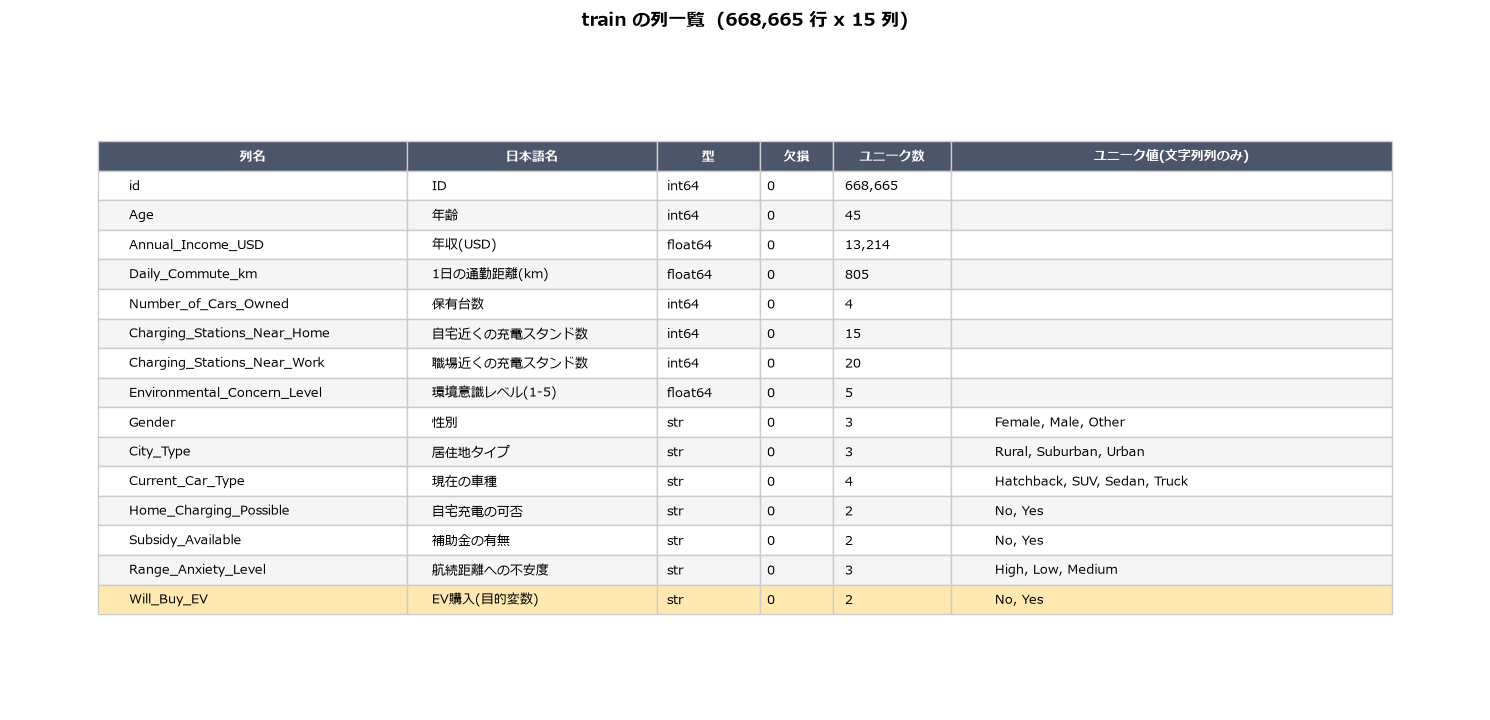

In [3]:
import matplotlib as mpl

# Windows 標準の日本語フォントを使う(無い場合は英字フォントのまま)
for _f in ["Meiryo", "Yu Gothic", "MS Gothic"]:
    if _f in {f.name for f in mpl.font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break

JP_NAMES = {
    "id": "ID",
    "Age": "年齢",
    "Annual_Income_USD": "年収(USD)",
    "Daily_Commute_km": "1日の通勤距離(km)",
    "Number_of_Cars_Owned": "保有台数",
    "Charging_Stations_Near_Home": "自宅近くの充電スタンド数",
    "Charging_Stations_Near_Work": "職場近くの充電スタンド数",
    "Environmental_Concern_Level": "環境意識レベル(1-5)",
    "Gender": "性別",
    "City_Type": "居住地タイプ",
    "Current_Car_Type": "現在の車種",
    "Home_Charging_Possible": "自宅充電の可否",
    "Subsidy_Available": "補助金の有無",
    "Range_Anxiety_Level": "航続距離への不安度",
    "Will_Buy_EV": "EV購入(目的変数)",
}

rows = []
for col in train.columns:
    is_str = train[col].dtype == object or pd.api.types.is_string_dtype(train[col])
    uniq = sorted(train[col].unique()) if is_str else []
    rows.append([
        col,
        JP_NAMES.get(col, ""),
        str(train[col].dtype),
        f"{train[col].isnull().sum():,}",
        f"{train[col].nunique():,}",
        ", ".join(map(str, uniq)) if is_str else "",
    ])

HEADERS = ["列名", "日本語名", "型", "欠損", "ユニーク数", "ユニーク値(文字列列のみ)"]
fig, ax = plt.subplots(figsize=(15, 0.42 * len(rows) + 1))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=HEADERS, loc="center", cellLoc="left",
               colWidths=[0.21, 0.17, 0.07, 0.05, 0.08, 0.30])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#cccccc")
    if r == 0:                                   # ヘッダー
        cell.set_facecolor("#4c566a")
        cell.set_text_props(color="white", weight="bold")
    elif rows[r - 1][0] == "Will_Buy_EV":        # 目的変数を強調
        cell.set_facecolor("#ffe9b0")
    elif r % 2 == 0:
        cell.set_facecolor("#f5f5f5")

ax.set_title(f"train の列一覧  ({train.shape[0]:,} 行 x {train.shape[1]} 列)",
             fontsize=13, weight="bold", pad=14)
plt.tight_layout()
plt.show()

## 目的変数の偏り

**ここが以降の見方を決める。** 購入者は全体の 17.5% しかいない。
つまり **約 6:1 の不均衡データ**で、件数のグラフを描くと購入者側が常に小さく潰れる。

そこで以降のグラフは、**上段に件数、下段に購入率**を並べて出す。

$$\text{購入率} = \frac{\text{そのグループの購入者数}}{\text{そのグループの総数}}$$

母数で割ることで、人数の多寡に影響されずにグループ同士を比較できる。
**件数で形を確認し、購入率で効果を読む**という二段構えにする。

In [4]:
print(train[TARGET].value_counts())
print("購入率:", overall_rate.round(4))

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64
購入率: 0.1746


## 仮説A — 数値列は、値が変わると購入率も変わるのか

年収や年齢のような数値列について、
**値が大きいほど(小さいほど)購入しやすい**という関係があるかを確かめる。

上段が件数の積み上げ、下段が同じ列の購入率。赤い破線は全体平均の 17.5%。

**下段は全列で縦軸を揃えてある。** 列ごとに自動調整すると、4 ポイントしか動かない列も
50 ポイント動く列も同じ振れ幅に見えてしまい、どれが効いているのか読めなくなるため。

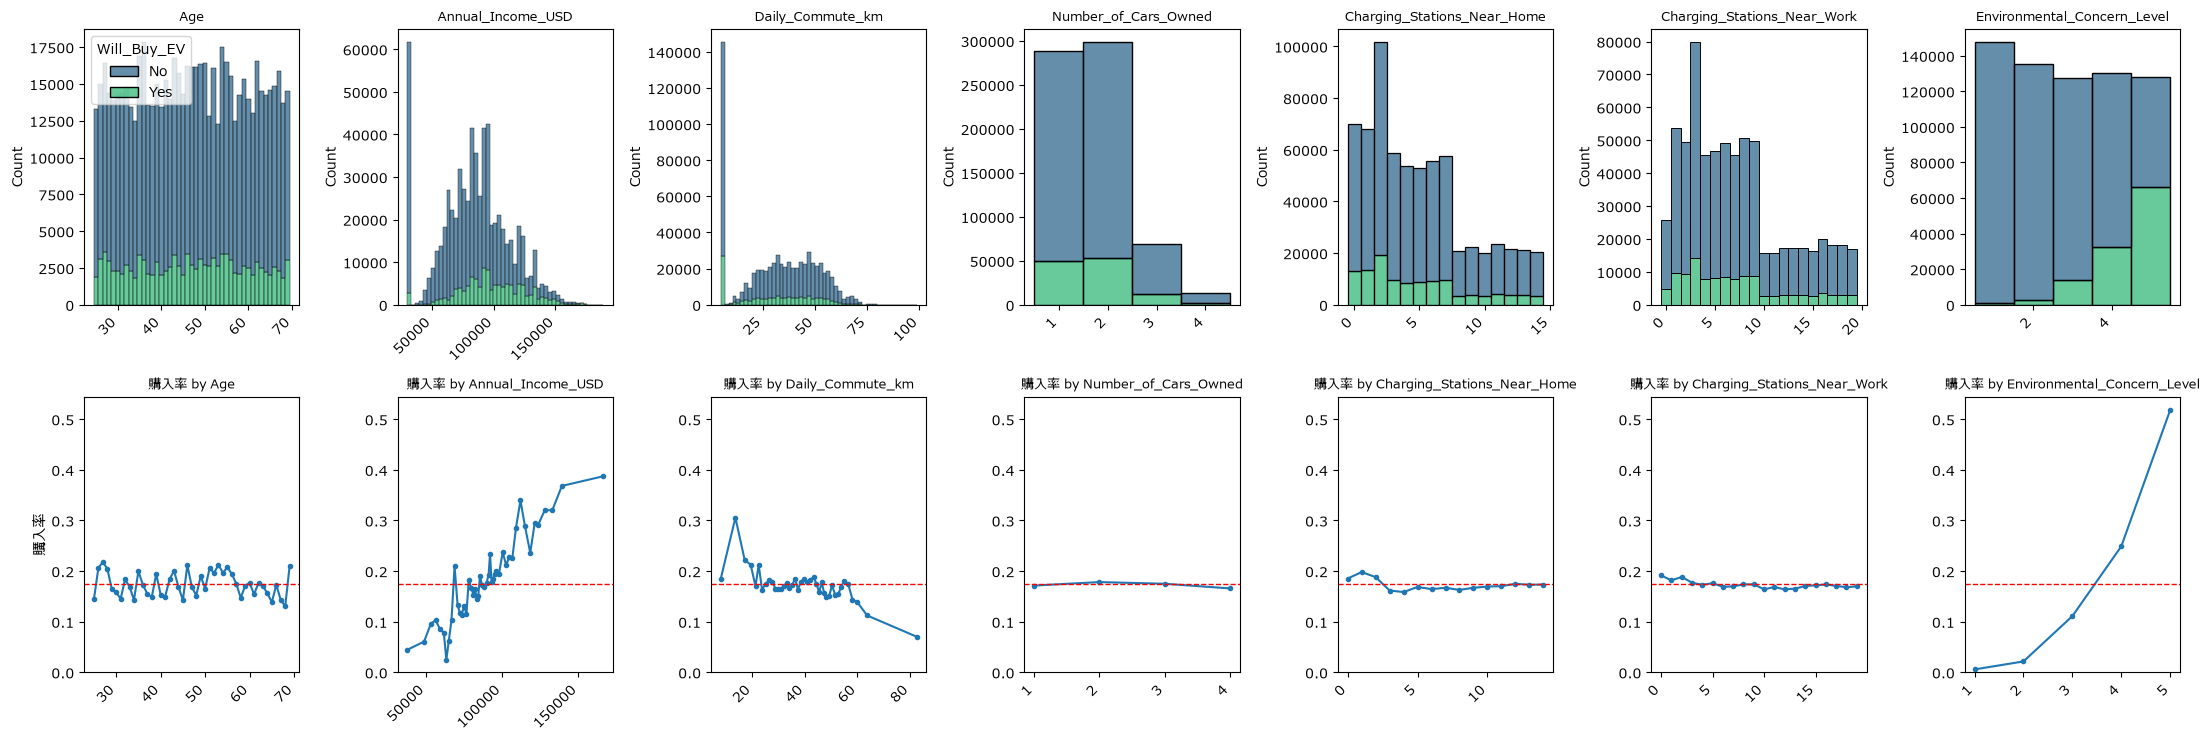

In [5]:
fig, axes = plt.subplots(2, len(NUM_COLS), figsize=(22, 7.5))
rates = {}

for i, col in enumerate(NUM_COLS):
    is_discrete = train[col].nunique() <= 50

    # 上段: 件数の積み上げ(購入/非購入)。分布の形を見るため縦軸は列ごとに最適化する
    sns.histplot(data=train, x=col, hue=TARGET, multiple="stack", palette="viridis",
                 discrete=is_discrete, bins="auto" if is_discrete else 50,
                 ax=axes[0, i], legend=(i == 0))
    axes[0, i].set_title(col, fontsize=9)
    axes[0, i].set_xlabel("")
    plt.setp(axes[0, i].get_xticklabels(), rotation=45, ha="right")

    # 下段: 同じ列の購入率。値が細かい列は50分位に区切ってから集計する
    group = (train[col] if is_discrete
             else pd.qcut(train[col], 50, duplicates="drop").apply(lambda iv: iv.mid))
    rates[col] = y.groupby(group, observed=True).mean()
    axes[1, i].plot(rates[col].index.astype(float), rates[col].values, marker="o", ms=3)
    axes[1, i].axhline(overall_rate, color="red", ls="--", lw=1)
    axes[1, i].set_title(f"購入率 by {col}", fontsize=9)
    plt.setp(axes[1, i].get_xticklabels(), rotation=45, ha="right")

# 下段は全列で縦軸を揃える。列ごとに自動調整すると、4ポイントしか動かない列も
# 50ポイント動く列も同じ振れ幅に見えてしまい、効き方の差が読めなくなる
y_max = max(r.max() for r in rates.values()) * 1.05
for ax in axes[1]:
    ax.set_ylim(0, y_max)
axes[1, 0].set_ylabel("購入率")

plt.tight_layout()

**上下を見比べると、件数だけでは分からないことが読み取れる。**

- **`Annual_Income_USD`**: 上段では中央が膨らんだ山にしか見えないが、
  下段は **2.5% から 38.7% までなめらかに右肩上がり**。明確に効いている
- **`Environmental_Concern_Level`**: レベル1の **0.6%** からレベル5の **51.8%** まで、
  たった5段階で 80 倍以上動く。**単独で最も強い**
- **`Age`**: 下段がほぼ平らで、赤い破線の上を行ったり来たりするだけ。
  「年齢が高いほど EV を買いそう」という直感は**このデータでは成り立たない**
- **`Number_of_Cars_Owned` / `Charging_Stations_Near_Work`**: どちらもほぼ平坦

また下段の左端を見ると、**年収 30,000 と通勤距離 5.0km に不自然な集中**がある。
データ生成時に下限でクリップされた痕跡と思われる。

**仮説Aは支持された。** ただし「効く列」と「効かない列」の差がはっきりしている。

## 仮説B — カテゴリ列も購入率を動かすのか

同じ見方をカテゴリ列にも当てる。上段が件数、下段が購入率。

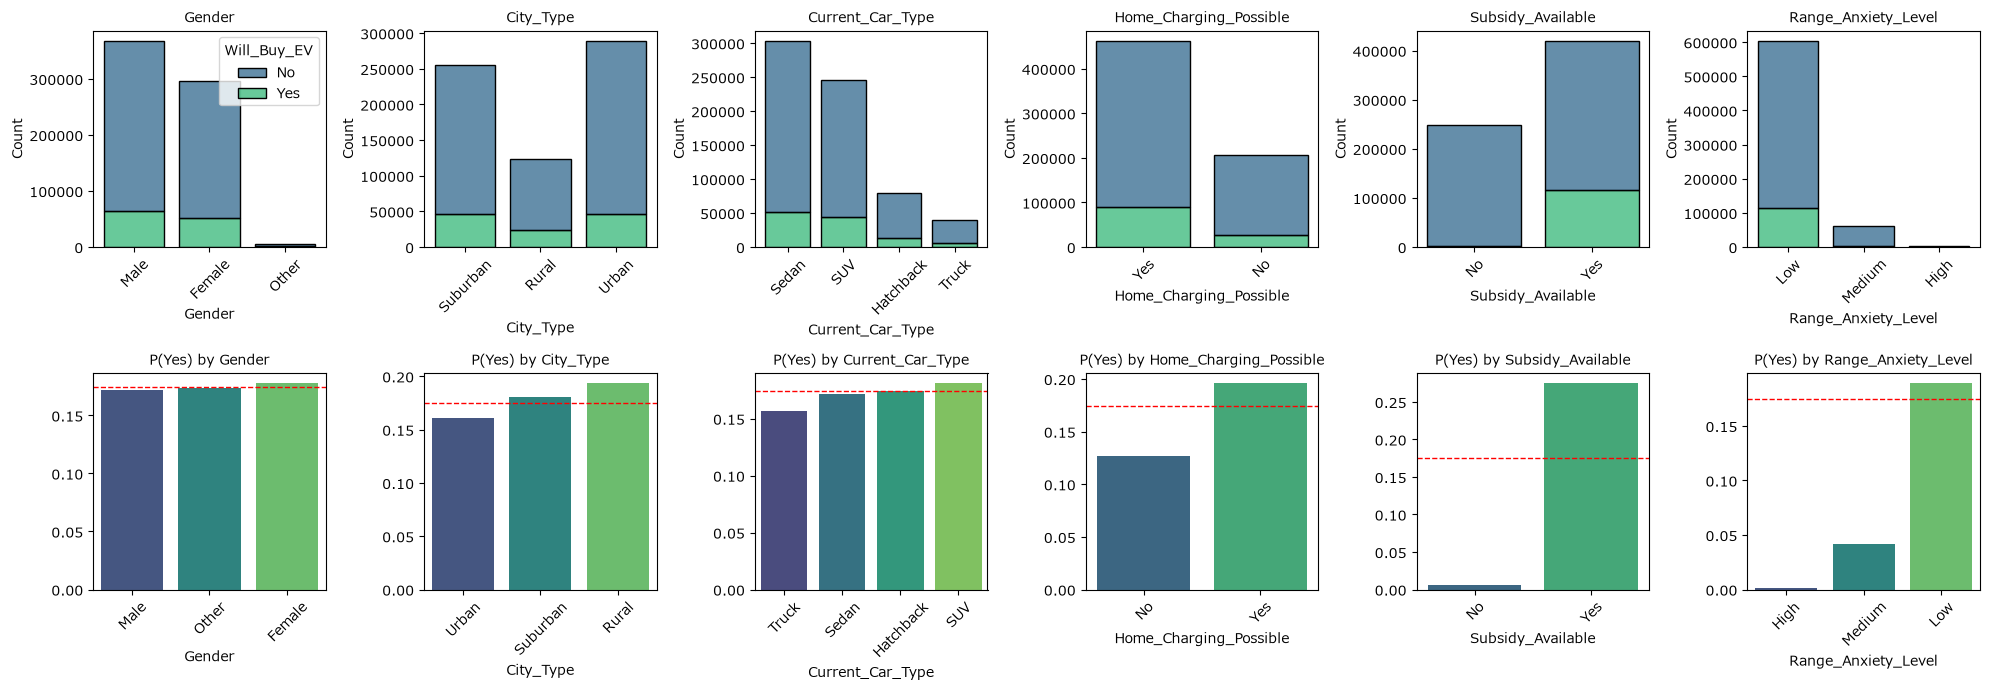

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, col in enumerate(CAT_COLS):
    sns.histplot(data=train, x=col, hue=TARGET, multiple="stack", palette="viridis",
                 shrink=0.8, ax=axes[0, i], legend=(i == 0))
    axes[0, i].set_title(col, fontsize=10); axes[0, i].tick_params(axis="x", rotation=45)
    rate = y.groupby(train[col]).mean().sort_values()
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index,
                palette="viridis", legend=False, ax=axes[1, i])
    axes[1, i].axhline(overall_rate, color="red", ls="--", lw=1)
    axes[1, i].set_title(f"P(Yes) by {col}", fontsize=10); axes[1, i].tick_params(axis="x", rotation=45)
plt.tight_layout()

In [7]:
summary = []
for col in CAT_COLS:
    rate_by_value = y.groupby(train[col], observed=True).mean().sort_values()
    summary.append({
        "列": col,
        "最も低い値": f"{rate_by_value.index[0]} ({rate_by_value.iloc[0]:.1%})",
        "最も高い値": f"{rate_by_value.index[-1]} ({rate_by_value.iloc[-1]:.1%})",
        "差(%ポイント)": round((rate_by_value.iloc[-1] - rate_by_value.iloc[0]) * 100, 1),
    })

pd.DataFrame(summary).sort_values("差(%ポイント)", ascending=False).reset_index(drop=True)

,列,最も低い値,最も高い値,差(%ポイント)
0,Subsidy_Available,No (0.6%),Yes (27.5%),26.9
1,Range_Anxiety_Level,High (0.1%),Low (18.9%),18.8
2,Home_Charging_Possible,No (12.7%),Yes (19.6%),6.9
3,City_Type,Urban (16.1%),Rural (19.3%),3.2
4,Current_Car_Type,Truck (15.6%),SUV (18.1%),2.5
5,Gender,Male (17.2%),Female (17.8%),0.5


**仮説Bも支持された。**

上段(件数)では `Subsidy_Available` の Yes と No がどちらも大きな棒に見えるだけだが、
下段(購入率)にすると **補助金ありが 27.5%、なしが 0.6% と 26.9 ポイントの差**があると分かる。
`Range_Anxiety_Level` も 18.8 ポイント動く。

**数値列の `Age`(4.1 ポイント)より遥かに大きい。**
カテゴリ列だからといって情報が乏しいわけではなく、**落とさずに使うべき**だと言える。

一方 `Gender` は 0.5 ポイントしか動かず、ほぼ無関係だった。

## 説明変数どうしの関係を見る

ここまでは **説明変数1つと目的変数** の関係だけを見てきた。
だが単独では効かないように見える列でも、**他の説明変数と関係していて、
まとまると意味を持つ**可能性がある。逆に、強く関係し合う列があれば
それらは**同じ情報を重複して持っている**ことになる。

型が混ざっているので、2つの指標を並べて見る。

| 指標 | 対象 | 範囲 | 何が分かるか |
|---|---|---|---|
| **Spearman 相関** | 数値列のみ | -1 〜 +1 | 関係の**向き**(正か負か)も分かる |
| **Cramér's V** | 全列(カテゴリを含む) | 0 〜 1 | 向きは分からないが、**型を問わず**関連の強さを測れる |

Cramér's V はクロス集計表のカイ二乗統計量を 0〜1 に正規化したもので、
カテゴリ列どうしでも使える。数値列は 10 分位に区切ってから算出する。

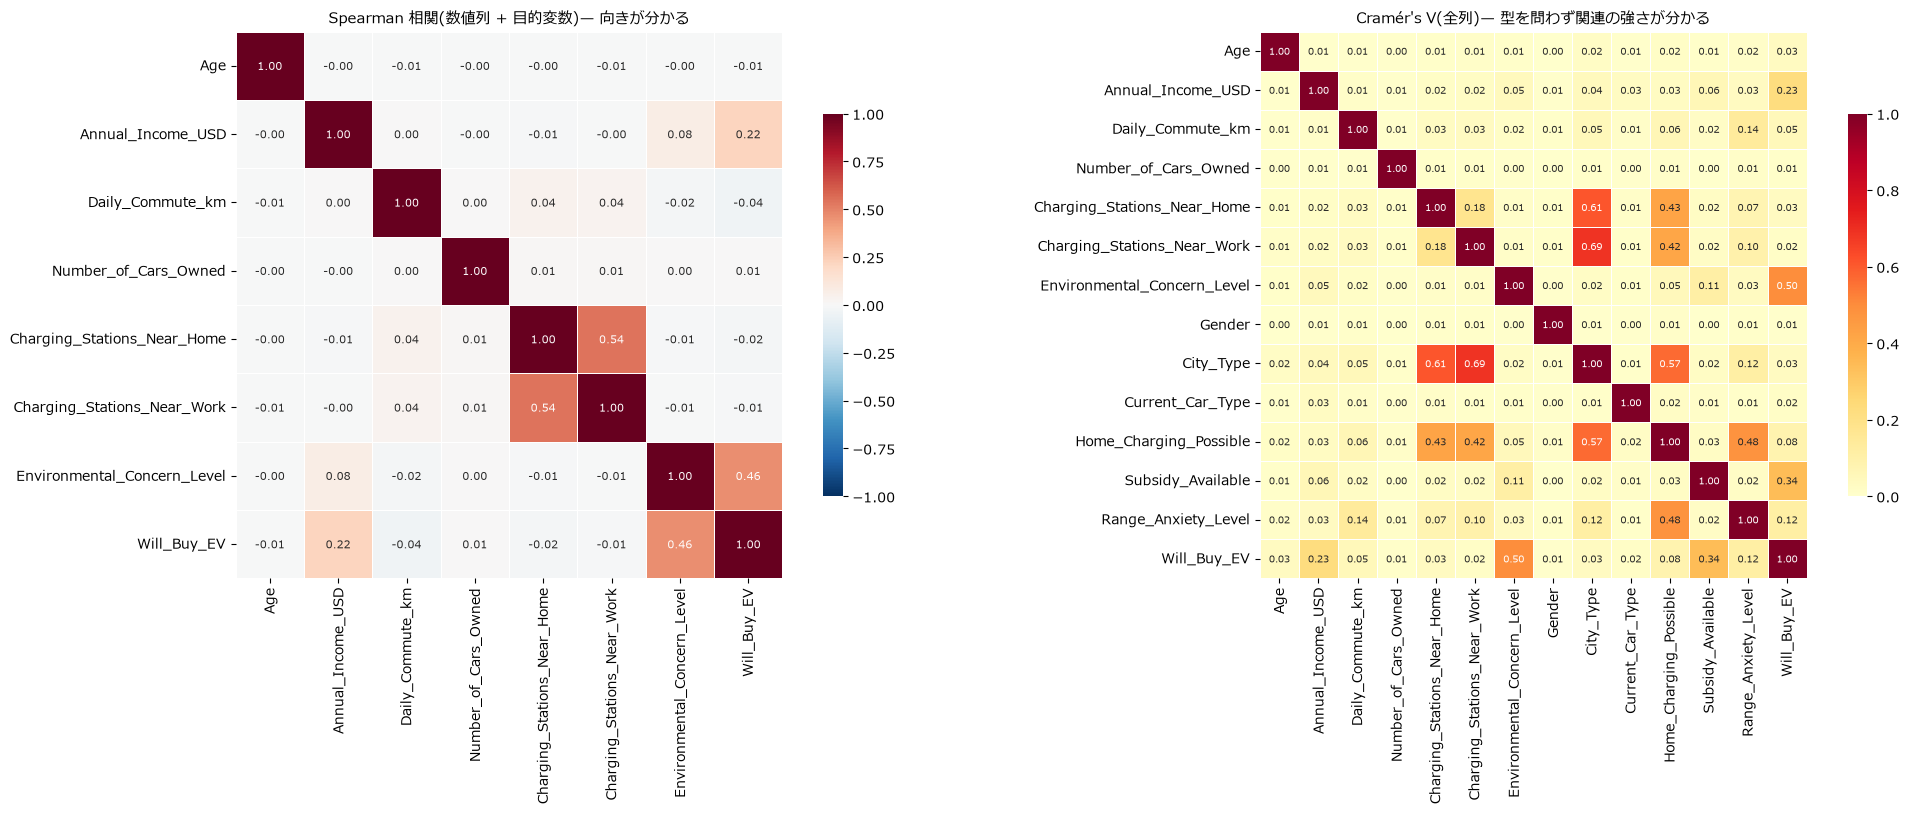

In [8]:
from scipy.stats import chi2_contingency


def cramers_v(a, b):
    """2列の関連の強さを 0〜1 で返す。カテゴリ列どうしでも使える。"""
    table = pd.crosstab(a, b)
    if min(table.shape) < 2:
        return np.nan
    chi2 = chi2_contingency(table)[0]
    return np.sqrt((chi2 / table.to_numpy().sum()) / (min(table.shape) - 1))


# Cramér's V 用に、値の細かい列は10分位に区切っておく
binned = {c: (train[c] if train[c].nunique() <= 20
              else pd.qcut(train[c], 10, duplicates="drop").astype(str))
          for c in NUM_COLS}
binned.update({c: train[c] for c in CAT_COLS})
binned[TARGET] = train[TARGET]

all_cols = NUM_COLS + CAT_COLS + [TARGET]
cramer = pd.DataFrame(np.nan, index=all_cols, columns=all_cols, dtype=float)
for i, a in enumerate(all_cols):
    for b in all_cols[i:]:
        value = 1.0 if a == b else cramers_v(binned[a], binned[b])
        cramer.loc[a, b] = cramer.loc[b, a] = value

# Spearman は数値列 + 目的変数(0/1)で算出する
numeric_frame = train[NUM_COLS].copy()
numeric_frame[TARGET] = y
spearman = numeric_frame.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(21, 8))
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": .7}, annot_kws={"size": 8}, ax=axes[0])
axes[0].set_title("Spearman 相関(数値列 + 目的変数)— 向きが分かる", fontsize=11)

sns.heatmap(cramer, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .7},
            annot_kws={"size": 7}, ax=axes[1])
axes[1].set_title("Cramér's V(全列)— 型を問わず関連の強さが分かる", fontsize=11)

plt.tight_layout()

In [9]:
explanatory = NUM_COLS + CAT_COLS
pairs = [(cramer.loc[a, b], a, b)
         for i, a in enumerate(explanatory) for b in explanatory[i + 1:]]
strength = np.array([v for v, _, _ in pairs])

print(f"説明変数どうしの Cramér's V: 中央値 {np.median(strength):.3f} / 最大 {strength.max():.3f}")
print(f"  0.4 を超える組は {int((strength > 0.4).sum())} 組\n")

print("関連の強い組 上位6つ:")
for v, a, b in sorted(pairs, reverse=True)[:6]:
    print(f"  {a:30s} x {b:30s} {v:.3f}")

説明変数どうしの Cramér's V: 中央値 0.014 / 最大 0.689
  0.4 を超える組は 6 組

関連の強い組 上位6つ:
  Charging_Stations_Near_Work    x City_Type                      0.689
  Charging_Stations_Near_Home    x City_Type                      0.610
  City_Type                      x Home_Charging_Possible         0.568
  Home_Charging_Possible         x Range_Anxiety_Level            0.478
  Charging_Stations_Near_Home    x Home_Charging_Possible         0.425
  Charging_Stations_Near_Work    x Home_Charging_Possible         0.416


**説明変数どうしは、ほとんどが無関係だった。** Cramér's V の中央値は 0.014 で、
ヒートマップもほぼ白い。**ただし1か所だけ濃い塊がある。**

### 発見 — 「住んでいる場所」を中心としたクラスタがある

| 組 | Cramér's V |
|---|---|
| `City_Type` × `Charging_Stations_Near_Work` | **0.689** |
| `City_Type` × `Charging_Stations_Near_Home` | **0.610** |
| `City_Type` × `Home_Charging_Possible` | **0.568** |
| `Home_Charging_Possible` × `Range_Anxiety_Level` | **0.478** |
| `Charging_Stations_Near_Home` × `Home_Charging_Possible` | **0.425** |

**`City_Type`(都市 / 郊外 / 地方)が充電環境まわりの列をまとめて決めている。**
都市なら充電スタンドが多く自宅充電はしにくい、地方ならその逆、という構造が読み取れる。
航続距離への不安も、自宅で充電できるかどうかと強く結びついている。

ここが重要な点で、**このクラスタの各列は単独ではほとんど効かなかった**
(目的変数との Cramér's V は `City_Type` 0.033、`Charging_Stations_Near_Work` 0.018)。
つまり **「単独で弱い列が、関係し合ってまとまっている」** という状況になっている。

→ **であれば、組み合わせると効くのではないか。** これを第3部で検証する。

### そのほか読み取れること

- **`Age` / `Gender` / `Number_of_Cars_Owned` は、どの列とも無関係**(すべて 0.02 未満)。
  目的変数とも無関係だったので、**本当に情報を持っていない列**だと確認できた
- `Annual_Income_USD` と `Environmental_Concern_Level` は
  目的変数への影響が最も大きい2列なのに、**互いの相関は 0.046** とほぼ独立。
  別々の情報を持っているので、両方使う価値がある

> **指標の読み方に注意。** `Charging_Stations_Near_Home` × `Near_Work` は
> Spearman では **0.544** と強いのに、Cramér's V では **0.179** と低く出ている。
> Cramér's V は**カテゴリ数が多い組ほど値が小さく出る**性質があるため。
> 順序のある数値列どうしは Spearman、カテゴリが絡む組は Cramér's V、と使い分ける。

### クラスタの中身を1組ずつ見る

ヒートマップは「関連が強い」としか教えてくれないので、
**どちらの値がどちらに対応しているのか**を組ごとに確かめる。

X 軸に一方、Y 軸にもう一方を置き、色は **X の各列内での割合**(縦方向に足すと 100%)。
「X がこの値のとき、Y はどう分布するか」を読む図になる。

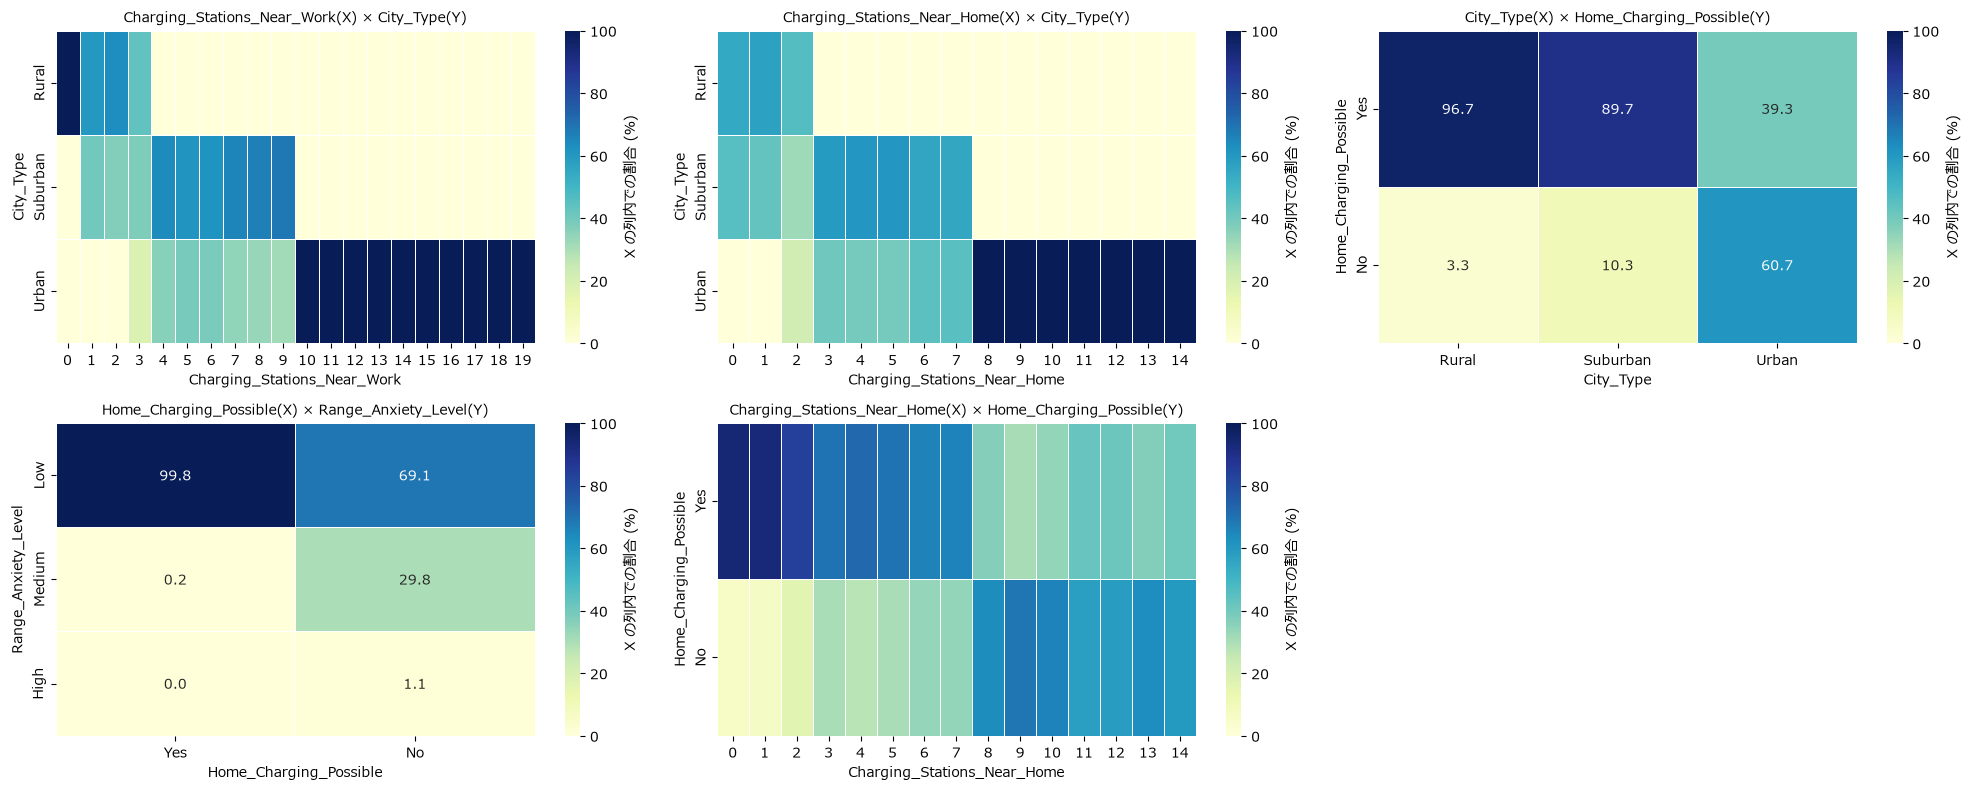

In [10]:
CLUSTER_PAIRS = [
    ("Charging_Stations_Near_Work", "City_Type"),
    ("Charging_Stations_Near_Home", "City_Type"),
    ("City_Type", "Home_Charging_Possible"),
    ("Home_Charging_Possible", "Range_Anxiety_Level"),
    ("Charging_Stations_Near_Home", "Home_Charging_Possible"),
]
# 順序のあるカテゴリは意味の順に並べる(アルファベット順だと傾向が読めなくなる)
ORDER = {
    "City_Type": ["Rural", "Suburban", "Urban"],
    "Range_Anxiety_Level": ["Low", "Medium", "High"],
    "Home_Charging_Possible": ["Yes", "No"],
}

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
for ax, (x_col, y_col) in zip(axes.ravel(), CLUSTER_PAIRS):
    # X の各値の中で Y がどう分布するか(列方向に正規化)
    share = pd.crosstab(train[y_col], train[x_col], normalize="columns")
    if y_col in ORDER:
        share = share.reindex(ORDER[y_col])
    if x_col in ORDER:
        share = share[ORDER[x_col]]

    sns.heatmap(share * 100, annot=share.shape[1] <= 6, fmt=".1f", cmap="YlGnBu",
                vmin=0, vmax=100, linewidths=.5,
                cbar_kws={"label": "X の列内での割合 (%)"}, ax=ax)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col}(X) × {y_col}(Y)", fontsize=10)

axes.ravel()[-1].axis("off")
plt.tight_layout()

In [11]:
# 数値で裏を取る。カテゴリごとに平均スタンド数を出す
print("City_Type 別の平均スタンド数")
print(train.groupby("City_Type")[["Charging_Stations_Near_Home",
                                  "Charging_Stations_Near_Work"]].mean()
      .reindex(ORDER["City_Type"]).round(2).to_string())

print("\n自宅充電の可否 別の平均スタンド数")
print(train.groupby("Home_Charging_Possible")[["Charging_Stations_Near_Home",
                                               "Charging_Stations_Near_Work"]].mean()
      .reindex(ORDER["Home_Charging_Possible"]).round(2).to_string())

print("\n自宅充電の可否 × 航続距離への不安(列内の割合 %)")
anxiety = pd.crosstab(train["Range_Anxiety_Level"], train["Home_Charging_Possible"],
                      normalize="columns") * 100
print(anxiety.reindex(ORDER["Range_Anxiety_Level"])[ORDER["Home_Charging_Possible"]]
      .round(1).to_string())

# 値域による住み分けを数字で確認する
print("\n値域による住み分け")
for col, threshold in [("Charging_Stations_Near_Home", 8),
                       ("Charging_Stations_Near_Work", 10)]:
    high = train[train[col] >= threshold]
    not_urban = int((high["City_Type"] != "Urban").sum())
    print(f"  {col} >= {threshold}: {len(high):,} 行中、"
          f"Urban でないのは {not_urban} 行 ({not_urban / len(high):.4%})")

City_Type 別の平均スタンド数
           Charging_Stations_Near_Home  Charging_Stations_Near_Work
City_Type                                                          
Rural                             1.07                         1.61
Suburban                          3.51                         5.38
Urban                             7.91                        11.15

自宅充電の可否 別の平均スタンド数
                        Charging_Stations_Near_Home  Charging_Stations_Near_Work
Home_Charging_Possible                                                          
Yes                                            3.92                         5.85
No                                             7.30                        10.16

自宅充電の可否 × 航続距離への不安(列内の割合 %)
Home_Charging_Possible   Yes    No
Range_Anxiety_Level               
Low                     99.8  69.1
Medium                   0.2  29.8
High                     0.0   1.1

値域による住み分け


  Charging_Stations_Near_Home >= 8: 150,407 行中、Urban でないのは 15 行 (0.0100%)
  Charging_Stations_Near_Work >= 10: 172,653 行中、Urban でないのは 4 行 (0.0023%)


**予想していたより、はるかに強い構造が出てきた。**
図を見ると色が**段階的に変わるのではなく、帯がくっきり切り替わっている。**

### 発見1 — スタンド数と `City_Type` は「値域で住み分け」ている

左上・中央上の図で、色のブロックが階段状に並んでいる。数字で確かめると:

| 条件 | 該当行数 | そのうち Urban でない行 |
|---|---|---|
| `Charging_Stations_Near_Home` ≥ 8 | 150,407 | **15 行(0.01%)** |
| `Charging_Stations_Near_Work` ≥ 10 | 172,653 | **4 行(0.002%)** |

**自宅近くのスタンドが 8 個以上なら、ほぼ確実に都市居住者。**
逆に地方(Rural)の自宅スタンド数は **0〜2 にほぼ限定**されている(3 個は 6 行だけ)。

これは「相関がある」という話ではなく、**データ生成時に `City_Type` ごとに
スタンド数の範囲を決めた痕跡**と考えられる。

**重要な含意: `City_Type` はスタンド数からほぼ復元できる。**
つまり両者は**同じ情報を重複して持っている**。
`City_Type` が単独では購入率をほとんど動かさなかった(目的変数との Cramér's V = 0.033)のは、
このためだと説明がつく。

### 発見2 — 自宅充電の可否が、航続距離への不安をほぼ決めている

| 自宅充電 | Low | Medium | High |
|---|---|---|---|
| **できる** | **99.8%** | 0.2% | 0.0% |
| できない | 69.1% | 29.8% | 1.1% |

**自宅で充電できる人は、ほぼ全員が「不安は低い」。**
できない人の約 3 割が Medium 以上の不安を抱えている。

### 連鎖をまとめると

```
都市に住む → スタンドは多い が 自宅充電できない → 航続距離への不安あり
地方に住む → スタンドは少ない が 自宅充電できる  → 不安なし
```

| | 自宅近くの平均スタンド数 | 職場近くの平均スタンド数 | 自宅充電できる割合 |
|---|---|---|---|
| 地方 | **1.07** | **1.61** | **96.7%** |
| 郊外 | 3.51 | 5.38 | 89.7% |
| 都市 | **7.91** | **11.15** | **39.3%** |

### ここから出てくる疑問

**この連鎖の中で、効き方が逆を向いている。**
自宅充電できない人は、**スタンドが多い場所に住んでいる**(平均 7.30 個 対 3.92 個)。

- スタンドが多い = 充電しやすい → 買いやすいはず
- しかしスタンドが多い場所の人は自宅充電できない → 買いにくいはず

**2つの効果が逆を向いて打ち消し合っている可能性がある。**
第1部で `Charging_Stations_Near_Home` の購入率がほぼ平坦だったのは、
これが原因かもしれない。

→ **もしそうなら、`Home_Charging_Possible` で分けて見れば、
打ち消しが解けてスタンド数の効果が現れるはず。** 第3部で確かめる。

---

# 第2部 単変量の考察

数値列とカテゴリ列を同じ土俵で並べ、単独でどれだけ効くかを比較する。
高カーディナリティの列は 10 分位に区切ってから集計する。

In [12]:
rows = []
for col in train.columns:
    if col in ("id", TARGET):
        continue
    if train[col].nunique() <= 20:
        group = train[col]
    else:
        group = pd.qcut(train[col], 10, duplicates="drop")
    rate_by_group = y.groupby(group, observed=True).mean()
    rows.append({
        "列": col,
        "購入率の幅(%ポイント)": round((rate_by_group.max() - rate_by_group.min()) * 100, 1),
        "最小": f"{rate_by_group.min():.1%}",
        "最大": f"{rate_by_group.max():.1%}",
        "ユニーク値数": train[col].nunique(),
    })

pd.DataFrame(rows).sort_values("購入率の幅(%ポイント)", ascending=False).reset_index(drop=True)

,列,購入率の幅(%ポイント),最小,最大,ユニーク値数
0,Environmental_Concern_Level,51.3,0.6%,51.8%,5
1,Annual_Income_USD,29.3,4.4%,33.7%,13214
2,Subsidy_Available,26.9,0.6%,27.5%,2
3,Range_Anxiety_Level,18.8,0.1%,18.9%,3
4,Daily_Commute_km,6.9,12.7%,19.6%,805
5,Home_Charging_Possible,6.9,12.7%,19.6%,2
6,Age,4.1,16.0%,20.1%,45
7,Charging_Stations_Near_Home,4.0,15.8%,19.8%,15
8,City_Type,3.2,16.1%,19.3%,3
9,Charging_Stations_Near_Work,2.8,16.4%,19.1%,20


## 分かったこと

**効く列と効かない列がはっきり分かれた。**

| | 列 | 幅 |
|---|---|---|
| 効く | `Environmental_Concern_Level` / `Annual_Income_USD` / `Subsidy_Available` / `Range_Anxiety_Level` | 18.8 〜 51.3 pt |
| ほぼ効かない | `Age` / `City_Type` / `Current_Car_Type` / `Number_of_Cars_Owned` / `Gender` | 0.5 〜 4.1 pt |

**そのうえで、`Annual_Income_USD` だけ他と性質が違う。**
2 番目に効いているのに、**値が 13,214 種類もある**。他の効く列は 2〜5 種類しかない。

ここで気になるのは、**この細かさをモデルがそのまま使えるのか**という点。

## 値はどれだけ細かいのか

各列のユニーク値数を数える。

In [13]:
pd.DataFrame({
    "nunique": [train[c].nunique() for c in NUM_COLS + CAT_COLS],
    "dtype": [str(train[c].dtype) for c in NUM_COLS + CAT_COLS],
}, index=NUM_COLS + CAT_COLS)

,nunique,dtype
Age,45,int64
Annual_Income_USD,13214,float64
Daily_Commute_km,805,float64
Number_of_Cars_Owned,4,int64
Charging_Stations_Near_Home,15,int64
Charging_Stations_Near_Work,20,int64
Environmental_Concern_Level,5,float64
Gender,3,str
City_Type,3,str
Current_Car_Type,4,str


**年収 13,214 種類、通勤距離 805 種類。**

ここで木モデルの仕様が問題になる。LightGBM も XGBoost も、学習前に数値列を
**既定 255 個のビン**にまとめてしまう。13,214 種類の値は 255 個に押し込められ、
**平均 52 種類の値が同じビンに潰れる**計算になる。

第1部で見たとおり年収の購入率は値に沿ってなめらかに動いていたので、
**潰すと情報が失われる可能性が高い。**

> 第2部のランキングは 10 分位で集計したため幅が 29.3 ポイントだったが、
> 第1部の図は 50 分位なので 2.5% → 38.7%(36 ポイント)と広く出る。
> **細かく見るほど差が大きくなること自体が、「値を丸めると情報が失われる」ことの傍証**になっている。

## 第2部の結論 — 次に検証すること

単変量の観察から、次の2つを次工程で試す。

| | 施策 | 根拠 |
|---|---|---|
| **施策1** | **値を丸めずに購入率を直接渡す**(Target Encoding)、ビン数を 255 から引き上げる | 年収は値に沿って購入率が動くのに、既定ビンでは 52 種類が同じ扱いになる |
| **施策2** | **カテゴリ列を落とさずモデルに渡す** | 補助金は 26.9 pt、航続距離不安は 18.8 pt 動く。数値列より効く |

> **施策1 の補足。** 前コンペ(S6E8)の合成データでも
> 「数値列を丸めずに厳密な値のまま Target Encoding する」施策が大きく効いた。
> **同じ手を当てにいく前に、同じ前提(値ごとに購入率が紐づく構造)がこのデータにもあるかを
> 上で確認した**、という順序になっている。

**施策2 は `02_baseline` で、施策1 は `03_feature_engineering` で検証する。**

---

# 第3部 次の仮説 — 組み合わせ(交差)で購入率は変わるか

ここまでは説明変数を1つずつ見てきた。
次に **「単独では説明できない、組み合わせ固有の効果」** があるかを調べる。

たとえば「高所得なら若くても買う」のような条件付きの傾向があれば、
年齢と収入を掛け合わせた特徴量を作る価値がある。

## 比べ方 — 購入率のままでは誤読する

購入率をそのまま比べると、**単に両方の列が効いているだけ**なのに
交互作用があるように見えてしまう。そこで **log-odds(対数オッズ)** に変換する。

$$\text{log-odds} = \log\frac{p}{1-p}$$

木モデルもロジスティック回帰も、内部ではこのスケールで足し算をしている。
**交互作用がなければ log-odds の線は平行になり**、平行でなくなったときだけ
「組み合わせに固有の効果がある」と言える。

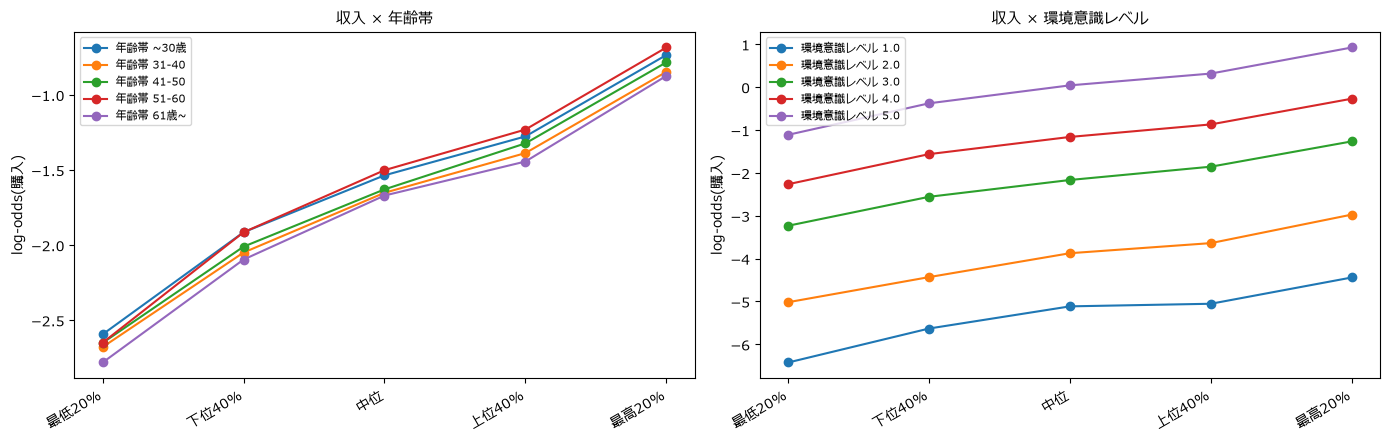

In [14]:
def to_log_odds(p):
    """購入率を log-odds に変換する。0/1 に張り付くと発散するのでクリップする。"""
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


age_band = pd.cut(train["Age"], [0, 30, 40, 50, 60, 100],
                  labels=["~30歳", "31-40", "41-50", "51-60", "61歳~"])
income_band = pd.qcut(train["Annual_Income_USD"], 5,
                      labels=["最低20%", "下位40%", "中位", "上位40%", "最高20%"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (row_key, row_name) in zip(
        axes, [(age_band, "年齢帯"), (train["Environmental_Concern_Level"], "環境意識レベル")]):
    rate_table = y.groupby([row_key, income_band], observed=True).mean().unstack()
    for label, series in to_log_odds(rate_table).iterrows():
        ax.plot(range(len(series)), series.values, marker="o", label=f"{row_name} {label}")
    ax.set_xticks(range(rate_table.shape[1]))
    ax.set_xticklabels(rate_table.columns, rotation=30, ha="right")
    ax.set_ylabel("log-odds(購入)")
    ax.set_title(f"収入 × {row_name}", fontsize=11)
    ax.legend(fontsize=8)
plt.tight_layout()

In [15]:
for row_key, row_name in [(age_band, "年齢帯"),
                          (train["Environmental_Concern_Level"], "環境意識レベル")]:
    rate_table = y.groupby([row_key, income_band], observed=True).mean().unstack()
    log_odds = to_log_odds(rate_table)
    lift = (log_odds.iloc[:, -1] - log_odds.iloc[:, 0]).round(2)
    print(f"【{row_name}別】収入 最低20% -> 最高20% の log-odds 上昇幅")
    print(lift.to_string())
    print(f"  ばらつき(標準偏差): {lift.std():.3f}"
          "   ← 0 に近いほど「相手によらず効き方が同じ」= 交互作用なし\n")

【年齢帯別】収入 最低20% -> 最高20% の log-odds 上昇幅
Age
~30歳     1.86
31-40    1.83
41-50    1.87
51-60    1.96
61歳~     1.91
  ばらつき(標準偏差): 0.050   ← 0 に近いほど「相手によらず効き方が同じ」= 交互作用なし

【環境意識レベル別】収入 最低20% -> 最高20% の log-odds 上昇幅
Environmental_Concern_Level
1.0    1.98
2.0    2.04
3.0    1.97
4.0    1.99
5.0    2.04
  ばらつき(標準偏差): 0.034   ← 0 に近いほど「相手によらず効き方が同じ」= 交互作用なし



**線がきれいに平行に並び、ばらつきも 0.05 と 0.03 だった。**

**収入の効き方は、年齢にも環境意識にもほとんど依存していない。**

特に環境意識との組み合わせは印象的で、購入率そのものは
**0.2%(意識1・低所得)から 71.6%(意識5・高所得)まで 350 倍以上**動くのに、
log-odds に直すと完全に平行になる。
つまりこのデータは **各列の効果が log-odds 上で単純に足し算されている**構造を持つ。

見かけ上の激しい差は交互作用ではなく、**主効果の足し算がオッズ比として掛け算になっていただけ**だった。

## ただし例外もあった — 自宅充電の可否 × 充電スタンド数

すべての組み合わせが加法的だったわけではない。

Home_Charging_Possible
No     205988
Yes    462677


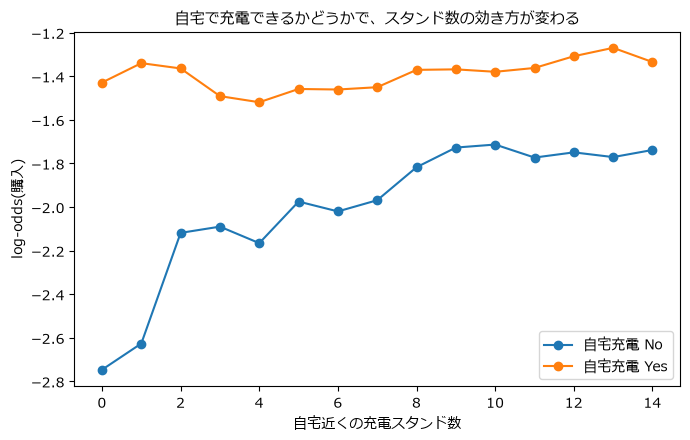

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for can_charge in ["No", "Yes"]:
    subset = train["Home_Charging_Possible"] == can_charge
    rate_by_stations = y[subset].groupby(
        train.loc[subset, "Charging_Stations_Near_Home"], observed=True).mean()
    ax.plot(rate_by_stations.index, to_log_odds(rate_by_stations).values,
            marker="o", label=f"自宅充電 {can_charge}")
ax.set_xlabel("自宅近くの充電スタンド数")
ax.set_ylabel("log-odds(購入)")
ax.set_title("自宅で充電できるかどうかで、スタンド数の効き方が変わる", fontsize=11)
ax.legend()
plt.tight_layout()

# 念のため件数も確認する(少数セルだと傾きがノイズになるため)
print(train.groupby(["Home_Charging_Possible"], observed=True).size().to_string())

**ここには本物の交互作用がある。**

- **自宅で充電できない人**: スタンドが 0 → 7 個で log-odds が **+0.78** 上がる
- **自宅で充電できる人**: **-0.02**。ほとんど変化しない

解釈は素直で、**自宅で充電できるなら近所のスタンドは要らない**ということ。
サンプル数も各数万件あり、ノイズではない。

> **紛らわしい例も1つあった。** 「自宅スタンド 10個以上 × 職場スタンド 0-2個」のセルだけ
> 購入率が 8.3% と極端に低く出たが、**該当は 12 行しかなかった**。
> 交互作用に見えるものが少数セルのノイズであることは珍しくないので、
> 傾きを読む前に必ず件数を確認する。

## 第3部の結論

**交互作用は「ほぼ存在しないが、一部にはある」。** ただし**特徴量として作るかは別の話**になる。

`Home_Charging_Possible × Charging_Stations_Near_Home` のような 2 列の条件分岐は、
**決定木が自力で表現できる**(先に `Home_Charging_Possible` で分割し、その先でスタンド数を見ればよい)。
わざわざ交互作用の特徴量を作っても、木にとって新しい情報にはならない可能性が高い。

| | 施策 | 根拠 |
|---|---|---|
| **施策3** | 交互作用の特徴量は「作る」より先に **本当に必要かを測る** | ほとんどの組み合わせが加法的。例外も木が自力で表現できる形 |

---

# まとめ — 次の工程に渡すもの

## 分かったこと

| | 結果 |
|---|---|
| データ | train 668,665 行 / test 286,571 行、**欠損なし**、購入率 **17.5%**(約 6:1 の不均衡) |
| 最も効く列 | `Environmental_Concern_Level`(51.3 pt)。値は 5 種類しかない |
| 次に効く列 | `Annual_Income_USD`(29.3 pt)。ただし **13,214 種類**あり、既定のビン 255 では潰れる |
| 効かない列 | `Age` は 4.1 pt、`Gender` は 0.5 pt。直感に反して年齢はほぼ効かない |
| データの構造 | 各列の効果が **log-odds 上で足し算**されている。交互作用はほぼない |
| 例外 | 自宅充電の可否 × スタンド数だけは本物の交互作用がある |
| 生成の痕跡 | 年収 30,000・通勤距離 5.0km に下限クリップと思われる集中 |

## 次工程で検証すること

| | 施策 | どこで |
|---|---|---|
| **施策1** | 値を丸めずに購入率を渡す(Target Encoding)、ビン数を引き上げる | `03_feature_engineering` / `04_train_and_evaluate` |
| **施策2** | カテゴリ列の有無でスコアを比較する | `02_baseline` |
| **施策3** | 交互作用の特徴量が本当に効くか測る(期待は低い) | `03_feature_engineering` |

**まず `02_baseline` で施策2 から確かめる。** 最も単純で、最も大きく動く可能性があるため。